# 01 — Data Loading & Preprocessing
Loads raw CSV, cleans Ram and Weight columns, drops ID, saves `laptop_data_features.csv`.

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
ld = pd.read_csv("Dataset-Laptops.csv")
print(f"Shape: {ld.shape}")
ld.info()

Shape: (1303, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 122.3 KB


In [5]:
ld.head(3)

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000


In [6]:
ld.describe()

,ID,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [7]:
# Check categorical columns
print("Categorical:", ld.select_dtypes(include='object').columns.tolist())
print("Numerical: ", ld.select_dtypes(include='number').columns.tolist())

Categorical: ['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']
Numerical:  ['ID', 'Inches', 'Price']


C:\Users\akshi\AppData\Local\Temp\ipykernel_25792\1621902642.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical:", ld.select_dtypes(include='object').columns.tolist())


In [8]:
# Check null values
ld.isnull().sum()

ID                  0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [9]:
# Clean Ram: remove 'GB' suffix, convert to int
ld['Ram'] = (
    ld['Ram']
    .str.replace('GB', '', case=False, regex=False)
    .str.strip()
    .astype(int)
)
print("Ram dtype:", ld['Ram'].dtype)
print(ld['Ram'].describe())

Ram dtype: int64
count    1303.000000
mean        8.382195
std         5.084665
min         2.000000
25%         4.000000
50%         8.000000
75%         8.000000
max        64.000000
Name: Ram, dtype: float64


In [10]:
# Clean Weight: remove 'kg' suffix, convert to float
ld['Weight'] = (
    ld['Weight']
    .str.replace('kg', '', case=False, regex=False)
    .str.strip()
    .astype(float)
)
print("Weight dtype:", ld['Weight'].dtype)
print(ld['Weight'].describe())

Weight dtype: float64
count    1303.000000
mean        2.038734
std         0.665475
min         0.690000
25%         1.500000
50%         2.040000
75%         2.300000
max         4.700000
Name: Weight, dtype: float64


In [11]:
# Drop ID — not a feature
ld.drop(columns=['ID'], inplace=True)

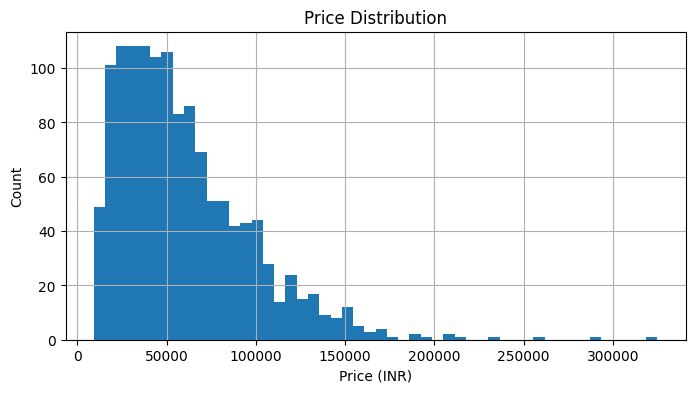

count      1303.000000
mean      59870.042910
std       37243.201786
min        9270.720000
25%       31914.720000
50%       52054.560000
75%       79274.246400
max      324954.720000
Name: Price, dtype: float64


In [12]:
# Price distribution
ld['Price'].hist(bins=50, figsize=(8, 4))
plt.title("Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()
print(ld['Price'].describe())

In [13]:
# Verify final state
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 112.1 KB


In [14]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print(f"Columns: {list(ld.columns)}")

Saved: laptop_data_features.csv
Shape: (1303, 11)
Columns: ['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']
